<a href="https://colab.research.google.com/github/Roberto-Ulises-Cruz-Olivares/Investigacion-de-Operaciones/blob/main/Tutorial_NetworkX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial de NetworkX

**Roberto Ulises Cruz Olivares**

**NetworkX es una biblioteca de Python para crear y analizar redes (grafos).

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

**Escribimos la red 1a como una lista de tuplas `(origen, destino, peso)`**

In [ ]:
# (origen, destino, peso) leídos de la imagen actividad_1_a
aristas_a = [(1, 2, 5), (1, 3, 1),
             (2, 4, 7), (2, 5, 1), (2, 6, 6),
             (3, 2, 2), (3, 4, 6), (3, 5, 7),
             (4, 3, 7), (4, 6, 4), (4, 7, 6),
             (5, 4, 3), (5, 6, 5), (5, 7, 9),
             (6, 2, 7), (6, 7, 2)]

# Posición (x, y) de cada nodo para dibujar parecido a la imagen (diccionario nodo: coordenada)
pos_a = {1: (0, 0), 2: (2, 1.5), 3: (2, -1.5), 4: (3.2, -0.2),
         5: (6, -1.5), 6: (6, 1.5), 7: (8, 0)}

**Función para dibujar una red y resaltar en rojo las aristas de la solución**

In [ ]:
def dibujar(G, pos, etiquetas, titulo, resaltar=[]):
    # Color de cada arista: rojo si está en la solución, gris si no
    colores = []
    grosor = []
    for u, v in G.edges():
        if (u, v) in resaltar or (not G.is_directed() and (v, u) in resaltar):
            colores.append('red')
            grosor.append(3)
        else:
            colores.append('gray')
            grosor.append(1)

    # Dirigido: flechas y aristas curvas. No dirigido: líneas rectas sin flecha
    if G.is_directed():
        curva, flecha = 'arc3,rad=0.12', '-|>'
    else:
        curva, flecha = 'arc3,rad=0', '-'

    plt.figure(figsize=(9, 5))
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', edgecolors='black', node_size=700)
    nx.draw_networkx_labels(G, pos, font_weight='bold')
    nx.draw_networkx_edges(G, pos, edge_color=colores, width=grosor, arrows=True, arrowstyle=flecha,
                           arrowsize=20, node_size=700, connectionstyle=curva)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=etiquetas, connectionstyle=curva)
    plt.title(titulo)
    plt.axis('off')
    plt.show()

## 1) Árbol de expansión mínima

**Buscamos las aristas que conecten todos los nodos sin formar ciclos y con el menor peso total:**

$$
\min \sum_{(i,j)\in T} w_{ij} \qquad \text{con } |T| = n-1 = 6 \text{ aristas y sin ciclos}
$$

**Hacemos la red no dirigida. Donde hay ida y vuelta ($2-6$ y $3-4$) nos quedamos con el peso menor**

In [ ]:
G_nd = nx.Graph()  # grafo no dirigido

for u, v, w in aristas_a:          # desempaquetamos cada tupla en u, v, w
    if G_nd.has_edge(u, v):        # si ya existe la arista (en cualquier sentido)
        G_nd[u][v]['weight'] = min(G_nd[u][v]['weight'], w)  # nos quedamos con el menor
    else:
        G_nd.add_edge(u, v, weight=w)

print('Nodos:', G_nd.number_of_nodes(), '  Aristas:', G_nd.number_of_edges())
print(G_nd.edges(data=True))

Nodos: 7   Aristas: 14
[(1, 2, {'weight': 5}), (1, 3, {'weight': 1}), (2, 4, {'weight': 7}), (2, 5, {'weight': 1}), (2, 6, {'weight': 6}), (2, 3, {'weight': 2}), (3, 4, {'weight': 6}), (3, 5, {'weight': 7}), (4, 6, {'weight': 4}), (4, 7, {'weight': 6}), (4, 5, {'weight': 3}), (5, 6, {'weight': 5}), (5, 7, {'weight': 9}), (6, 7, {'weight': 2})]


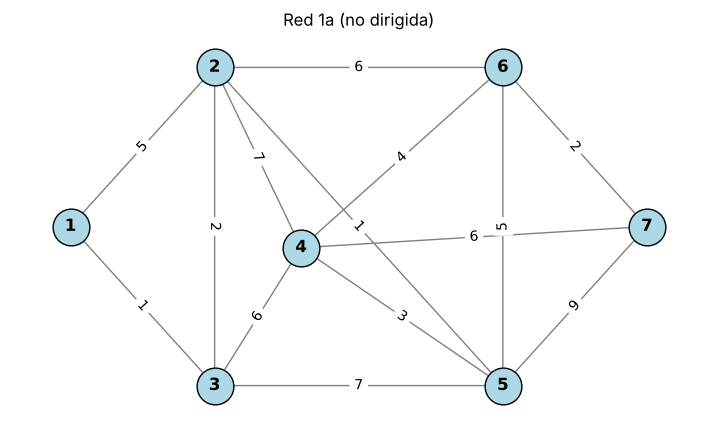

In [ ]:
pesos_nd = nx.get_edge_attributes(G_nd, 'weight')
dibujar(G_nd, pos_a, pesos_nd, 'Red 1a (no dirigida)')

**Usamos `nx.minimum_spanning_tree`, que regresa el árbol como un nuevo grafo (por defecto usa el algoritmo de Kruskal)**

In [ ]:
T = nx.minimum_spanning_tree(G_nd, weight='weight', algorithm='kruskal')

# sorted(..., key=...) ordena las aristas por su peso (lambda e: e[2]['weight'])
aristas_T = sorted(T.edges(data=True), key=lambda e: e[2]['weight'])

for u, v, d in aristas_T:
    print(f'{u} - {v}   peso = {d["weight"]}')

# T.size(weight='weight') suma los pesos de todas las aristas del árbol
print('\nPeso total del árbol:', int(T.size(weight='weight')))

1 - 3   peso = 1
2 - 5   peso = 1
2 - 3   peso = 2
6 - 7   peso = 2
4 - 5   peso = 3
4 - 6   peso = 4

Peso total del árbol: 13


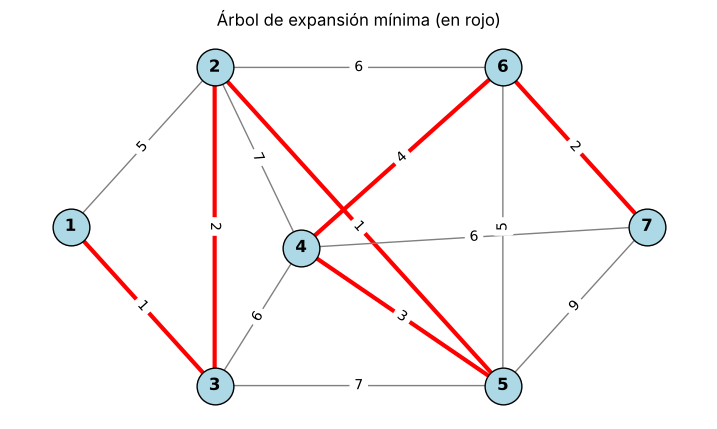

In [ ]:
dibujar(G_nd, pos_a, pesos_nd, 'Árbol de expansión mínima (en rojo)', resaltar=list(T.edges()))

**Solución: el árbol está formado por las aristas $1-3,\ 2-5,\ 2-3,\ 6-7,\ 4-5,\ 4-6$**

$$
\text{Peso total} = 1 + 1 + 2 + 2 + 3 + 4 = \boxed{13}
$$

## 2) Ruta más corta

**Buscamos la ruta de menor costo del nodo 1 al nodo 7, con $x_{ij}=1$ si se usa el arco $(i,j)$:**

$$
\min \sum_{(i,j)} c_{ij}\,x_{ij}
\qquad \text{s.a.}\quad
\sum_{j} x_{ij} - \sum_{j} x_{ji} =
\begin{cases}
\;\;\,1 & i = 1 \\
-1 & i = 7 \\
\;\;\,0 & \text{en otro caso}
\end{cases}
\qquad x_{ij}\in\{0,1\}
$$

**Creamos la red dirigida**

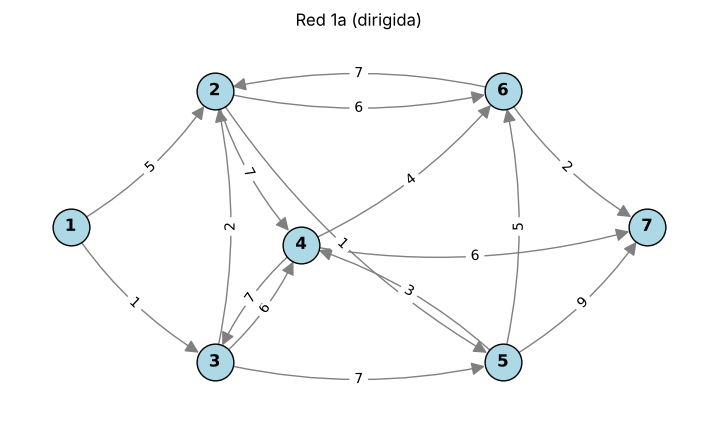

In [ ]:
G_d = nx.DiGraph()                     # grafo dirigido
G_d.add_weighted_edges_from(aristas_a) # agrega todos los arcos (u, v, peso) de una vez

pesos_d = nx.get_edge_attributes(G_d, 'weight')
dibujar(G_d, pos_a, pesos_d, 'Red 1a (dirigida)')

**Como los pesos son positivos usamos Dijkstra. `nx.single_source_dijkstra_path_length` da la distancia mínima del nodo 1 a cada nodo**

In [ ]:
distancias = nx.single_source_dijkstra_path_length(G_d, 1)
print('Distancia mínima desde el nodo 1:')
for nodo in sorted(distancias):
    print(f'  nodo {nodo}: {distancias[nodo]}')

Distancia mínima desde el nodo 1:
  nodo 1: 0
  nodo 2: 3
  nodo 3: 1
  nodo 4: 7
  nodo 5: 4
  nodo 6: 9
  nodo 7: 11


In [ ]:
costo = nx.dijkstra_path_length(G_d, 1, 7)
rutas = list(nx.all_shortest_paths(G_d, 1, 7, weight='weight'))  # list() convierte el generador en lista

print('Costo mínimo de 1 a 7:', costo)
print('Rutas más cortas:')
for r in rutas:
    print('  ', ' -> '.join(str(n) for n in r))

Costo mínimo de 1 a 7: 11
Rutas más cortas:
   1 -> 3 -> 2 -> 6 -> 7
   1 -> 3 -> 2 -> 5 -> 6 -> 7


**Hay dos rutas con el mismo costo, las dibujamos. `zip(r, r[1:])` forma los arcos de la ruta**

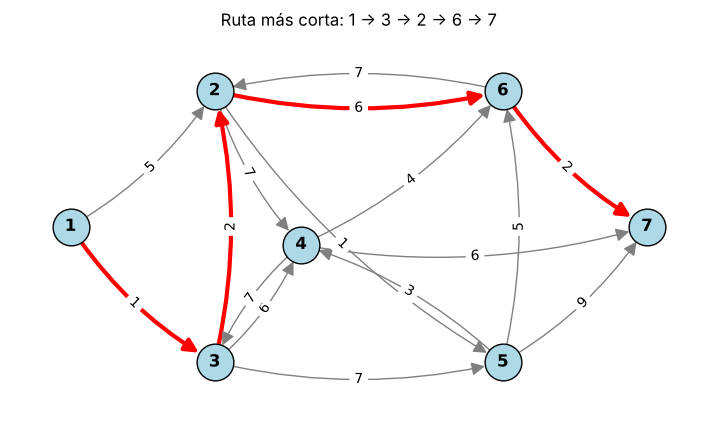

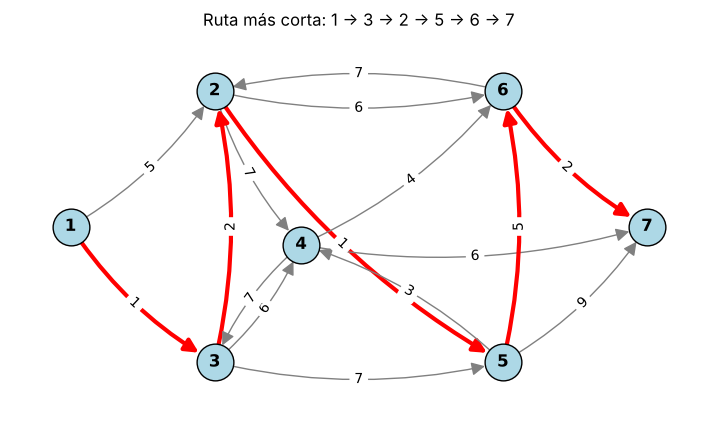

In [ ]:
for r in rutas:
    arcos_ruta = list(zip(r, r[1:]))   # [(1,3), (3,2), ...]
    dibujar(G_d, pos_a, pesos_d, 'Ruta más corta: ' + ' → '.join(str(n) for n in r), resaltar=arcos_ruta)

**Solución: el costo mínimo de 1 a 7 es $\boxed{11}$ con dos rutas:**

- $1 \to 3 \to 2 \to 5 \to 6 \to 7 \qquad (1+2+1+5+2 = 11)$
- $1 \to 3 \to 2 \to 6 \to 7 \qquad (1+2+6+2 = 11)$

## 3) Flujo máximo

**Buscamos el mayor flujo $f$ que se puede enviar del nodo 1 al nodo 5, con $x_{ij}$ el flujo en el arco $(i,j)$:**

$$
\max \; f
\qquad \text{s.a.}\quad
\sum_{j} x_{ij} - \sum_{j} x_{ji} =
\begin{cases}
\;\;\,f & i = 1 \\
-f & i = 5 \\
\;\;\,0 & \text{en otro caso}
\end{cases}
\qquad 0 \le x_{ij} \le c_{ij}
$$

**En la imagen, el número junto al nodo $i$ es la capacidad de $i \to j$. Solo agregamos los arcos con capacidad mayor a 0, usando el atributo `capacity`**

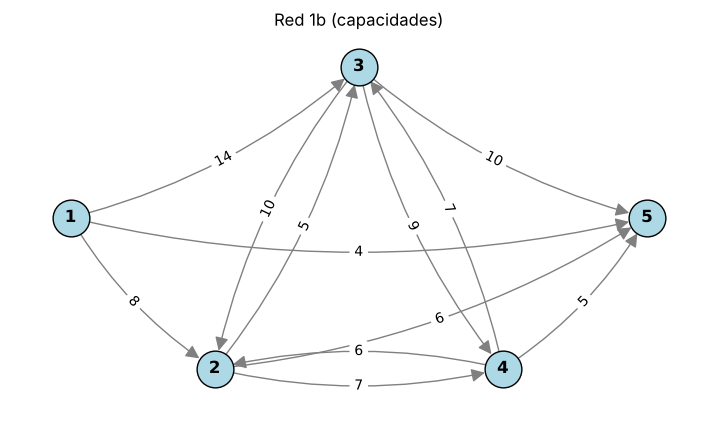

In [ ]:
# (origen, destino, capacidad) leídos de la imagen actividad_1_b
arcos_b = [(1, 2, 8), (1, 3, 14), (1, 5, 4),
           (2, 3, 5), (2, 4, 7), (2, 5, 6),
           (3, 2, 10), (3, 4, 9), (3, 5, 10),
           (4, 2, 6), (4, 3, 7), (4, 5, 5)]

G_f = nx.DiGraph()
for u, v, c in arcos_b:
    G_f.add_edge(u, v, capacity=c)   # atributo 'capacity'

pos_b = {1: (0, 0), 2: (2, -2), 3: (4, 2), 4: (6, -2), 5: (8, 0)}

capacidades = nx.get_edge_attributes(G_f, 'capacity')
dibujar(G_f, pos_b, capacidades, 'Red 1b (capacidades)')

**Usamos `nx.maximum_flow`, que regresa el valor del flujo máximo y un diccionario donde `flujo[u][v]` es el flujo en el arco $(u,v)$**

In [ ]:
valor, flujo = nx.maximum_flow(G_f, 1, 5, capacity='capacity')  # desempaquetamos la tupla

print('Flujo máximo de 1 a 5:', valor)
print('\nFlujo en cada arco (flujo / capacidad):')
for u, v in G_f.edges():
    if flujo[u][v] > 0:
        print(f'  {u} -> {v}:  {flujo[u][v]} / {G_f[u][v]["capacity"]}')

Flujo máximo de 1 a 5: 25

Flujo en cada arco (flujo / capacidad):
  1 -> 2:  7 / 8
  1 -> 3:  14 / 14
  1 -> 5:  4 / 4
  2 -> 3:  2 / 5
  2 -> 5:  6 / 6
  3 -> 4:  6 / 9
  3 -> 5:  10 / 10
  4 -> 2:  1 / 6
  4 -> 5:  5 / 5


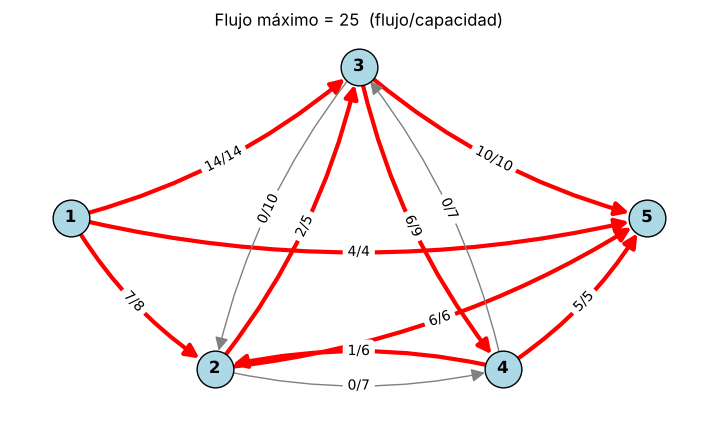

In [ ]:
# Etiquetas "flujo/capacidad" y resaltamos los arcos que llevan flujo
etiquetas_f = {}
usados = []
for u, v in G_f.edges():
    etiquetas_f[(u, v)] = f'{flujo[u][v]}/{G_f[u][v]["capacity"]}'
    if flujo[u][v] > 0:
        usados.append((u, v))

dibujar(G_f, pos_b, etiquetas_f, f'Flujo máximo = {valor}  (flujo/capacidad)', resaltar=usados)

**Comprobamos con `nx.minimum_cut`: el flujo máximo debe ser igual a la capacidad del corte mínimo**

In [ ]:
cap_corte, (S, T_lado) = nx.minimum_cut(G_f, 1, 5)
print('Capacidad del corte mínimo:', cap_corte)
print('S =', S, '   T =', T_lado)

Capacidad del corte mínimo: 25
S = {1, 2, 3, 4}    T = {5}


**Solución: todos los arcos que llegan al nodo 5 quedan llenos ($4+6+10+5$)**

$$
\text{Flujo máximo de 1 a 5} = \boxed{25}
$$

**Referencia:** https://networkx.org/documentation/stable/index.html